# Implement Selective State Space Model (Mamba Block)

**Difficulty**: 🔴 Hard

**Companies**: DeepMind, Google, Anthropic, AI Startups

---

### Problem Statement

State Space Models (SSMs) provide an alternative to Transformers for sequence modeling, offering linear-time complexity in sequence length. **Mamba** (S6) introduces **selective** state spaces where the SSM parameters B and C are input-dependent, allowing the model to selectively focus on or ignore parts of the input.

The core idea: a continuous-time SSM `h'(t) = Ah(t) + Bx(t), y(t) = Ch(t) + Dx(t)` is discretized using zero-order hold (ZOH), then the recurrence is run with input-dependent B and C matrices.

Your task is to implement the discretization, selective scan, and a full Mamba block, then validate on a selective copying task.

---

### Requirements

1. **Discretization** — Convert continuous parameters (A, B) to discrete (A_bar, B_bar) using zero-order hold: `A_bar = exp(delta * A)`, `B_bar = (exp(delta * A) - I) * A^{-1} * B` (simplified to `delta * B` for diagonal A).
2. **Selective Scan** — Implement the SSM recurrence `h_t = A_bar * h_{t-1} + B_bar * x_t, y_t = C * h_t + D * x_t` with input-dependent B and C.
3. **Mamba Block** — Full block with linear projections, Conv1d, SiLU activation, selective scan, and output projection.
4. **Validation** — Test on a selective copying task and compare with a simple RNN baseline.

---

### Constraints

- ✅ Use PyTorch for all implementations.
- ✅ A should be diagonal (HiPPO-initialized or simple negative real values).
- ✅ Keep dimensions manageable: d_model=32, d_state=16, d_conv=4.
- ❌ Do **not** use any pre-built Mamba/SSM libraries.

---

<details>
  <summary>💡 Hint</summary>

  - For diagonal A, the ZOH discretization simplifies: `A_bar = exp(delta * A)` (element-wise), `B_bar = delta * B` (simplified form).
  - The selective scan processes the sequence step by step: `h_t = A_bar_t * h_{t-1} + B_bar_t * x_t`. This is sequential but can be parallelized with a scan operation.
  - In the Mamba block, delta (step size), B, and C are all projected from the input, making them input-dependent. This is the key difference from linear time-invariant (LTI) SSMs.
  - The selective copying task: given a sequence with special marker tokens, the model must copy specific tokens to the output. This tests the model's ability to selectively remember.

</details>

---

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [49]:
# --- Data: Selective Copying Task ---
# Sequence has tokens and special markers. The model must copy marked tokens to the end.
# Input:  [a, _, b, _, MARK, c, _, d, MARK, _, PAD, PAD]
# Output: [_, _, _, _, _, _, _, _, _, _, c, d]  (copy tokens after MARK positions)

torch.manual_seed(42)

def generate_selective_copy_data(n_samples, seq_len=20, vocab_size=8, n_copies=3):
    """
    Generate selective copying task data.

    Tokens 0..vocab_size-1 are regular tokens.
    Token `vocab_size` is the COPY marker.
    Token `vocab_size+1` is PAD/blank.

    The task: certain positions are marked, and the model must output
    the marked tokens (in order) at the end of the sequence.
    """
    blank = vocab_size + 1
    marker = vocab_size

    inputs = torch.full((n_samples, seq_len), blank, dtype=torch.long)
    targets = torch.full((n_samples, seq_len), blank, dtype=torch.long)

    for i in range(n_samples):
        # Place random tokens in the first part
        content_len = seq_len - n_copies  # leave room for output
        tokens = torch.randint(0, vocab_size, (content_len,))
        inputs[i, :content_len] = tokens

        # Randomly select positions to mark
        mark_positions = torch.randperm(content_len)[:n_copies].sort().values

        # Place markers right before the tokens to copy
        marked_tokens = []
        for pos in mark_positions:
            inputs[i, pos] = marker
            if pos + 1 < content_len:
                marked_tokens.append(tokens[pos + 1] if pos + 1 < len(tokens) else tokens[pos])
            else:
                marked_tokens.append(tokens[pos])

        # Target: marked tokens at the end
        for j, tok in enumerate(marked_tokens):
            targets[i, seq_len - n_copies + j] = tok

    return inputs, targets


vocab_size = 8
seq_len = 20
n_copies = 3
train_inputs, train_targets = generate_selective_copy_data(2000, seq_len, vocab_size, n_copies)
test_inputs, test_targets = generate_selective_copy_data(500, seq_len, vocab_size, n_copies)

print(f'Input shape: {train_inputs.shape}')
print(f'Example input:  {train_inputs[0].tolist()}')
print(f'Example target: {train_targets[0].tolist()}')
print(f'Vocab: 0-{vocab_size-1}=tokens, {vocab_size}=MARK, {vocab_size+1}=BLANK')

Input shape: torch.Size([2000, 20])
Example input:  [6, 3, 4, 8, 2, 7, 4, 4, 8, 1, 8, 6, 2, 2, 7, 4, 3, 9, 9, 9]
Example target: [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 2, 1, 6]
Vocab: 0-7=tokens, 8=MARK, 9=BLANK


In [50]:
# --- Part 1: Selective Scan ---

def selective_scan(x, delta, A, B, C, D):
    """
    Selective scan (S6) - the core SSM recurrence with input-dependent parameters.

    Discretize continuous (A, B) to discrete (A_bar, B_bar) using ZOH,
    then run the recurrence.

    Args:
        x (Tensor): Input, shape (B, L, D) where D is the expanded inner dimension.
        delta (Tensor): Step size, shape (B, L, D). Input-dependent.
        A (Tensor): State matrix, shape (D, N) where N is state dimension. Learned parameter.
        B (Tensor): Input matrix, shape (B, L, N). Input-dependent.
        C (Tensor): Output matrix, shape (B, L, N). Input-dependent.
        D (Tensor): Skip connection, shape (D,). Learned parameter.

    Returns:
        y (Tensor): Output, shape (B, L, D).
    """
    batch, seq_len, d_inner = x.shape
    n = A.shape[1]  # state dimension
    assert A.shape[0] == d_inner, A.shape
    assert B.shape == C.shape, C.shape
    assert B.shape == (batch, seq_len, n), B.shape
    assert delta.shape == (batch, seq_len, d_inner), delta.shape
    assert D.shape == (d_inner,), D.shape

    # TODO: Step 1 - Discretize A and B using ZOH
    # delta has shape (B, L, D), A has shape (D, N)
    A_bar = torch.exp(delta.unsqueeze(-1) * A)  # -> shape (B, L, D, N)
    B_bar = delta.unsqueeze(-1) * B.unsqueeze(2) # -> shape (B, L, D, N)
    assert A_bar.shape == (batch, seq_len, d_inner, n), A_bar.shape
    assert B_bar.shape == (batch, seq_len, d_inner, n), B_bar.shape
    # TODO: Step 2 - Run the recurrence
    # Initialize hidden state h of shape (B, D, N) to zeros
    # For each timestep t:
    #   h = A_bar[:, t] * h + B_bar[:, t] * x[:, t, :, None]
    #   y_t = (h * C[:, t, None, :]).sum(-1)  # shape (B, D)
    h = torch.zeros(batch, d_inner, n)
    y = []
    for t in range(seq_len):
        h = A_bar[:, t] * h + B_bar[:, t] * x[:, t, :, None]
        y.append((h * C[:, t, None, :]).sum(-1))

    y = torch.stack(y, dim=1)
    # TODO: Step 3 - Add skip connection: y = y + D * x
    y = y + D * x
    return y

print('selective_scan defined.')

selective_scan defined.


In [51]:
# --- Part 2: Mamba Block ---

class MambaBlock(nn.Module):
    """
    Mamba block: the core building block of the Mamba architecture.

    Architecture:
        input -> linear proj (expand) -> split into two paths
        Path 1: Conv1d -> SiLU -> SSM (selective scan)
        Path 2: SiLU (gate)
        Combine: path1 * path2 -> linear proj (contract) -> output
    """
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        """
        Args:
            d_model (int): Model dimension.
            d_state (int): SSM state dimension N.
            d_conv (int): Local convolution width.
            expand (int): Expansion factor for inner dimension.
        """
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.d_inner = d_model * expand

        # TODO: Input projection: d_model -> 2 * d_inner (for x and gate paths)
        self.in_proj = nn.Linear(d_model, 2 * self.d_inner, bias=False)

        # TODO: Conv1d on the x path
        self.conv1d = nn.Conv1d(self.d_inner, self.d_inner, d_conv,
                                padding=d_conv-1, groups=self.d_inner)

        # TODO: SSM parameter projections (input-dependent delta, B, C)
        self.x_proj = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)  # delta, B, C
        self.delta_proj = nn.Linear(1, self.d_inner)  # project scalar delta to d_inner

        # TODO: Learnable SSM parameters
        # A: initialized as negative log-spaced values (diagonal, shape d_inner x d_state)
        self.A_log = nn.Parameter(torch.log(torch.arange(1, d_state+1).float().repeat(self.d_inner, 1)))
        # D: skip connection, shape (d_inner,)
        self.D = nn.Parameter(torch.ones(self.d_inner))

        # TODO: Output projection: d_inner -> d_model
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    def forward(self, x):
        """
        Args:
            x (Tensor): Input, shape (B, L, d_model).

        Returns:
            Tensor: Output, shape (B, L, d_model).
        """
        batch_size, L, d_model = x.shape
        # TODO: Project input to get x_path and gate_path
        x_path, gate_path = torch.split(self.in_proj(x), self.d_inner, dim=-1)
        # TODO: Apply Conv1d to x_path (remember to handle causal padding)
        assert x_path.shape == (batch_size, L, self.d_inner), x.shape
        x_path = self.conv1d(x_path.transpose(1, 2))[:, :, :L].transpose(1, 2)
        assert x_path.shape == (batch_size, L, self.d_inner), x.shape
        # TODO: Apply SiLU activation
        x_path = F.silu(x_path)
        assert x_path.shape == (batch_size, L, self.d_inner), x.shape
        # TODO: Project x to get delta, B, C
        B, C, delta = torch.split(self.x_proj(x_path), self.d_state, -1)
        assert B.shape == (batch_size, L, self.d_state), B.shape
        assert delta.shape == (batch_size, L, 1)
        # TODO: Apply softplus to delta, then project to d_inner
        delta = F.softplus(self.delta_proj(delta))
        assert delta.shape == (batch_size, L, self.d_inner)
        # TODO: Compute A = -exp(A_log)
        A = -torch.exp(self.A_log)
        assert A.shape == (self.d_inner, self.d_state), A.shape
        assert x_path.shape == (batch_size, L, self.d_inner)
        # TODO: Run selective_scan(x, delta, A, B, C, D)
        y = selective_scan(x_path, delta, A, B, C, self.D)
        # TODO: Gate and project output
        assert y.shape[-1] == self.d_inner
        y = y * F.silu(gate_path)
        return self.out_proj(y)

# Test
block = MambaBlock(d_model=32, d_state=16, d_conv=4, expand=2)
test_x = torch.randn(2, 10, 32)
test_out = block(test_x)
print(f'MambaBlock: input {test_x.shape} -> output {test_out.shape}')
print(f'Parameters: {sum(p.numel() for p in block.parameters()):,}')

MambaBlock: input torch.Size([2, 10, 32]) -> output torch.Size([2, 10, 32])
Parameters: 9,792


In [52]:
# --- Part 3: Full Mamba Model and RNN Baseline ---

class MambaModel(nn.Module):
    """Stack of Mamba blocks for sequence modeling."""
    def __init__(self, vocab_size, d_model=32, d_state=16, n_layers=2, output_size=None):
        super().__init__()
        if output_size is None:
            output_size = vocab_size
        self.embedding = nn.Embedding(vocab_size + 2, d_model)  # +2 for marker and blank
        self.layers = nn.ModuleList([MambaBlock(d_model, d_state) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, output_size)

    def forward(self, x):
        h = self.embedding(x)
        for layer in self.layers:
            h = h + layer(h)  # residual
        h = self.norm(h)
        return self.head(h)


class RNNBaseline(nn.Module):
    """Simple RNN baseline for comparison."""
    def __init__(self, vocab_size, d_model=32, n_layers=2, output_size=None):
        super().__init__()
        if output_size is None:
            output_size = vocab_size
        self.embedding = nn.Embedding(vocab_size + 2, d_model)
        self.rnn = nn.GRU(d_model, d_model, n_layers, batch_first=True)
        self.head = nn.Linear(d_model, output_size)

    def forward(self, x):
        h = self.embedding(x)
        h, _ = self.rnn(h)
        return self.head(h)


full_vocab = vocab_size + 2  # tokens + marker + blank
mamba_model = MambaModel(vocab_size, d_model=32, d_state=16, n_layers=2, output_size=full_vocab)
rnn_model = RNNBaseline(vocab_size, d_model=32, n_layers=2, output_size=full_vocab)

print(f'Mamba parameters: {sum(p.numel() for p in mamba_model.parameters()):,}')
print(f'RNN parameters: {sum(p.numel() for p in rnn_model.parameters()):,}')

Mamba parameters: 20,298
RNN parameters: 13,322


In [53]:
# --- Part 4: Training ---

def train_model(model, train_inputs, train_targets, n_epochs=100, batch_size=128, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    blank = vocab_size + 1

    model.train()
    for epoch in range(n_epochs):
        perm = torch.randperm(len(train_inputs))
        epoch_loss = 0
        n_batches = 0

        for i in range(0, len(train_inputs), batch_size):
            x = train_inputs[perm[i:i+batch_size]]
            y = train_targets[perm[i:i+batch_size]]

            logits = model(x)
            # Only compute loss on the output positions (last n_copies positions)
            loss = F.cross_entropy(logits[:, -n_copies:].reshape(-1, logits.size(-1)),
                                  y[:, -n_copies:].reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        if (epoch + 1) % 25 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}')

    return losses


print('Training Mamba model...')
mamba_losses = train_model(mamba_model, train_inputs, train_targets, n_epochs=100)

print('\nTraining RNN baseline...')
rnn_losses = train_model(rnn_model, train_inputs, train_targets, n_epochs=100)

Training Mamba model...
  Epoch 25/100, Loss: 0.5924
  Epoch 50/100, Loss: 0.2865
  Epoch 75/100, Loss: 0.1941
  Epoch 100/100, Loss: 0.1342

Training RNN baseline...
  Epoch 25/100, Loss: 0.8814
  Epoch 50/100, Loss: 0.3987
  Epoch 75/100, Loss: 0.3313
  Epoch 100/100, Loss: 0.2857


=== Validation ===
Mamba  - Token Acc: 0.8000, Sequence Acc: 0.4740
RNN    - Token Acc: 0.8373, Sequence Acc: 0.5660


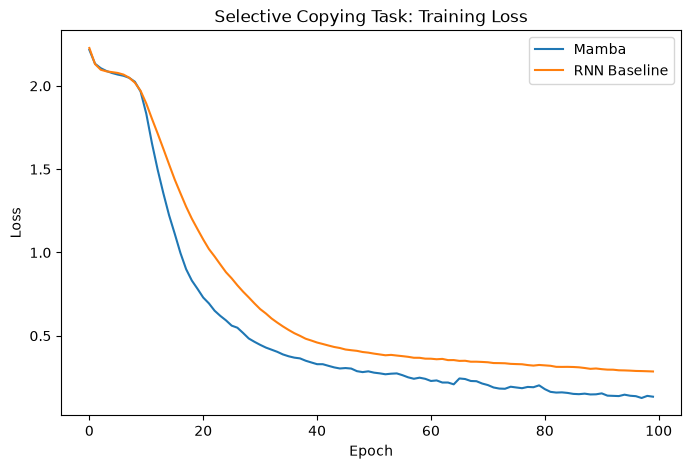

PASSED: Mamba loss decreased during training
PASSED: Mamba achieves reasonable accuracy (0.8000)

All validations passed!


In [54]:
# --- Validation ---

def evaluate_model(model, test_inputs, test_targets, n_copies):
    model.eval()
    with torch.no_grad():
        logits = model(test_inputs)
        preds = logits[:, -n_copies:].argmax(dim=-1)
        targets = test_targets[:, -n_copies:]

        # Token-level accuracy
        token_acc = (preds == targets).float().mean().item()

        # Sequence-level accuracy (all copies correct)
        seq_acc = (preds == targets).all(dim=-1).float().mean().item()

    return token_acc, seq_acc


mamba_token_acc, mamba_seq_acc = evaluate_model(mamba_model, test_inputs, test_targets, n_copies)
rnn_token_acc, rnn_seq_acc = evaluate_model(rnn_model, test_inputs, test_targets, n_copies)

print('=== Validation ===')
print(f'Mamba  - Token Acc: {mamba_token_acc:.4f}, Sequence Acc: {mamba_seq_acc:.4f}')
print(f'RNN    - Token Acc: {rnn_token_acc:.4f}, Sequence Acc: {rnn_seq_acc:.4f}')

# Plot training curves
plt.figure(figsize=(8, 5))
plt.plot(mamba_losses, label='Mamba')
plt.plot(rnn_losses, label='RNN Baseline')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Selective Copying Task: Training Loss')
plt.legend()
plt.show()

# Checks
assert mamba_losses[-1] < mamba_losses[0], 'Mamba loss should decrease!'
print('PASSED: Mamba loss decreased during training')

assert mamba_token_acc > 0.3, f'Mamba token accuracy too low: {mamba_token_acc:.4f}'
print(f'PASSED: Mamba achieves reasonable accuracy ({mamba_token_acc:.4f})')

print('\nAll validations passed!')